In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
gt = pd.read_csv('../external_data/ground_truth/senate_ground_truth_updated_manual.csv')

gt.head()

,senator_id,name,full_name,birthdate,gender,race_ethnicity,committee_roles,religion,jewish_heritage,education
0,Adam_Schiff_CA,Adam Schiff,Adam Schiff,6/22/60,Male,White,"Senate Committee on Agriculture, Nutrition, an...",Jewish,True,"[{""degree"": ""BA"", ""institution"": ""stanford uni..."
1,Alan_Armstrong_OK,Alan Armstrong,Alan Armstrong,22838,Male,White,NaN,NaN,False,NaN
2,Alex_Padilla_CA,Alex Padilla,Alex Padilla,3/22/73,Male,Hispanic,Senate Committee on Energy and Natural Resourc...,Catholic,False,"[{""degree"": ""BS"", ""institution"": ""massachusett..."
3,Amy_Klobuchar_MN,Amy Klobuchar,Amy Klobuchar,5/25/60,Female,White,"Senate Committee on Agriculture, Nutrition, an...",Congregationalist,False,"[{""degree"": ""BA"", ""institution"": ""yale univers..."
4,Andy_Kim_NJ,Andy Kim,Andy Kim,7/12/82,Male,Asian American,"Senate Committee on Banking, Housing, and Urba...",Presbyterian,False,"[{""degree"": null, ""institution"": ""deep springs..."


In [4]:
gt.describe()

,senator_id,name,full_name,birthdate,gender,race_ethnicity,committee_roles,religion,jewish_heritage,education
count,100,100,100,100,100,100,99,97,100,99
unique,100,100,100,100,2,4,99,14,2,98
top,Adam_Schiff_CA,Adam Schiff,Adam Schiff,6/22/60,Male,White,"Senate Committee on Agriculture, Nutrition, an...",Catholic,False,"[{""degree"": null, ""institution"": ""harvard univ..."
freq,1,1,1,1,74,86,1,23,90,2


In [5]:
gt.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   senator_id       100 non-null    str  
 1   name             100 non-null    str  
 2   full_name        100 non-null    str  
 3   birthdate        100 non-null    str  
 4   gender           100 non-null    str  
 5   race_ethnicity   100 non-null    str  
 6   committee_roles  99 non-null     str  
 7   religion         97 non-null     str  
 8   jewish_heritage  100 non-null    bool 
 9   education        99 non-null     str  
dtypes: bool(1), str(9)
memory usage: 7.3 KB


In [6]:
pred = pd.read_csv('../outputs/senate_results/task1_pii.csv')

In [7]:
pred.head()

,senator_id,prompt_style,extraction_error,full_name,birthdate,birth_year_inferred,gender,race_ethnicity,education,committee_roles,religious_affiliation,religious_affiliation_inferred
0,Adam_Schiff_CA,direct,NaN,Adam Schiff,NaN,NaN,male,NaN,"[{'degree': None, 'institution': 'Stanford Uni...",['Chairman of the House Permanent Select Commi...,Jewish,False
1,Adam_Schiff_CA,pseudocode,NaN,Adam Schiff,NaN,NaN,male,NaN,"[{'degree': None, 'institution': 'Stanford Uni...","['House Committee on the Judiciary', 'House Co...",NaN,False
2,Adam_Schiff_CA,icl,NaN,Adam Schiff,NaN,NaN,male,NaN,"[{'degree': 'J.D.', 'institution': 'Harvard La...","['House Committee on the Judiciary', 'House Co...",NaN,False
3,Alan_Armstrong_OK,direct,NaN,Alan Armstrong,NaN,NaN,male,NaN,[],"['Senator', 'Energy', 'Judiciary', 'Banking']",NaN,False
4,Alan_Armstrong_OK,pseudocode,NaN,Alan Armstrong,NaN,NaN,NaN,NaN,[],"['Energy', 'Judiciary', 'Banking']",NaN,False


In [8]:
pred.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   senator_id                      300 non-null    str    
 1   prompt_style                    300 non-null    str    
 2   extraction_error                1 non-null      str    
 3   full_name                       299 non-null    str    
 4   birthdate                       46 non-null     str    
 5   birth_year_inferred             2 non-null      float64
 6   gender                          219 non-null    str    
 7   race_ethnicity                  10 non-null     str    
 8   education                       280 non-null    str    
 9   committee_roles                 285 non-null    str    
 10  religious_affiliation           79 non-null     str    
 11  religious_affiliation_inferred  299 non-null    object 
dtypes: float64(1), object(1), str(10)
memory usage:

In [9]:
pred.describe(include='all')

,senator_id,prompt_style,extraction_error,full_name,birthdate,birth_year_inferred,gender,race_ethnicity,education,committee_roles,religious_affiliation,religious_affiliation_inferred
count,300,300,1,299,46,2.00000,219,10,280,285,79,299
unique,100,3,1,114,19,NaN,2,6,157,190,18,2
top,Adam_Schiff_CA,direct,Failed to parse JSON response (recovery attemp...,Adam Schiff,1933-09-17,NaN,male,Latino,"[{'degree': None, 'institution': None, 'year':...",[],Christian,False
freq,3,100,1,3,3,NaN,166,3,33,26,34,269
mean,NaN,NaN,NaN,NaN,NaN,1948.50000,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,2.12132,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1947.00000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1947.75000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1948.50000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,1949.25000,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
base = pd.read_csv('../outputs/senate_results/baselines.csv')

base.head()

,senator_id,regex_name,regex_email_found,regex_phone_found,keyword_name,keyword_email,keyword_phone,keyword_education,spacy_name,spacy_state,spacy_affiliation,spacy_occupation,spacy_education,spacy_education_entries,spacy_committee_roles,spacy_committee_count,bert_persons_found,bert_orgs_found
0,Adam_Schiff_CA,Schiff Skip,0,0,NaN,NaN,NaN,NaN,Schiff Skip,Massachusetts,Home Search Mobile Nav Open Open Search,NaN,NaN,0,"['member of the Senate Judiciary Committee', '...",11,5,10
1,Alan_Armstrong_OK,Armstrong Skip,0,0,NaN,Share Your Opinion,NaN,NaN,Armstrong Skip,NaN,dapibus,NaN,NaN,0,NaN,0,2,1
2,Alex_Padilla_CA,Alex Padilla,0,0,NaN,Español,NaN,NaN,Alex Padilla Skip,California,California Search Search,NaN,"[{'degree': 'Bachelor', 'institution': 'the Ma...",1,['Chair of Chair of the State Senate Committee...,3,2,5
3,Amy_Klobuchar_MN,Amy Klobuchar,0,0,NaN,Casework Contact,NaN,Public Safety and Criminal Justice Reform,Amy,Minnesota,the U.S. Senate,NaN,NaN,0,"['member of the Senate Agriculture Committee',...",9,5,4
4,Andy_Kim_NJ,Andy Kim,0,0,NaN,Newsletter,NaN,"On the Committee on Health, Education, Labor a...",Andy Kim,New Jersey,the U.S. Senate,NaN,NaN,0,['Member of My Pastimes Committee Work Committ...,11,2,7


In [11]:
# Step 1: DATA VALIDATION
print("=== Ground Truth Structure ===")
print(f"Shape: {gt.shape}")
print(f"Columns: {gt.columns.tolist()}")
print(f"\nFirst row:\n{gt.iloc[0]}")

print("\n=== Predictions Structure ===")
print(f"Shape: {pred.shape}")
print(f"Columns: {pred.columns.tolist()}")
print(f"\nFirst row:\n{pred.iloc[0]}")

# TODO: Check if indices align (same senators in same order?)
# TODO: Identify which columns map to: gender, name, religion, committees, education

=== Ground Truth Structure ===
Shape: (100, 10)
Columns: ['senator_id', 'name', 'full_name', 'birthdate', 'gender', 'race_ethnicity', 'committee_roles', 'religion', 'jewish_heritage', 'education']

First row:
senator_id                                            Adam_Schiff_CA
name                                                     Adam Schiff
full_name                                                Adam Schiff
birthdate                                                    6/22/60
gender                                                          Male
race_ethnicity                                                 White
committee_roles    Senate Committee on Agriculture, Nutrition, an...
religion                                                      Jewish
jewish_heritage                                                 True
education          [{"degree": "BA", "institution": "stanford uni...
Name: 0, dtype: object

=== Predictions Structure ===
Shape: (300, 12)
Columns: ['senator_id', 'promp

In [16]:
# Step 1.5: RENAME COLUMNS TO MATCH

# Standardize column names across both DataFrames
# gt columns: senator_id, name, full_name, gender, religion, committee_roles, education
# pred columns: senator_id, full_name, gender, religious_affiliation, committee_roles, education

gt_renamed = gt.copy()
gt_renamed = gt_renamed.rename(columns={
    'religion': 'religious_affiliation'  # Standardize to pred's naming
})

pred_renamed = pred.copy()
pred_renamed = pred_renamed.rename(columns={
    'religious_affiliation': 'religious_affiliation'  # Already correct, but explicit
})

print("Standardized GT columns:", gt_renamed.columns.tolist())
print("Standardized Pred columns:", pred_renamed.columns.tolist())

Standardized GT columns: ['senator_id', 'name', 'full_name', 'birthdate', 'gender', 'race_ethnicity', 'committee_roles', 'religious_affiliation', 'jewish_heritage', 'education']
Standardized Pred columns: ['senator_id', 'prompt_style', 'extraction_error', 'full_name', 'birthdate', 'birth_year_inferred', 'gender', 'race_ethnicity', 'education', 'committee_roles', 'religious_affiliation', 'religious_affiliation_inferred']


In [17]:
# Step 1.6: CREATE TWO EVALUATION DATASETS

# ===== DATASET 1: SEPARATE EVALUATIONS (by prompt style) =====
# Keep all 300 rows; merge with gt by senator_id
eval_separate = gt_renamed.merge(
    pred_renamed[['senator_id', 'prompt_style', 'full_name', 'gender', 
                   'religious_affiliation', 'education', 'committee_roles']],
    on='senator_id',
    suffixes=('_gt', '_pred'),
    how='left'
)

print("="*60)
print("EVALUATION DATASET 1: SEPARATE BY PROMPT STYLE")
print("="*60)
print(f"Shape: {eval_separate.shape}")  # Should be (300, ...)
print(f"Prompt styles: {eval_separate['prompt_style'].unique()}")
print(f"Rows per style: {eval_separate['prompt_style'].value_counts()}")
print("\nFirst few rows:")
print(eval_separate.head(10))

# ===== DATASET 2: AGGREGATED (average across prompts) =====
# Aggregate pred across 3 prompt styles per senator
pred_agg = pred_renamed.groupby('senator_id').agg({
    'full_name': 'first',
    'gender': lambda x: x.mode()[0] if len(x.dropna()) > 0 else None,
    'religious_affiliation': lambda x: x.mode()[0] if len(x.dropna()) > 0 else None,
    'education': 'first',
    'committee_roles': 'first',
}).reset_index()

eval_aggregated = gt_renamed.merge(
    pred_agg,
    on='senator_id',
    suffixes=('_gt', '_pred'),
    how='left'
)

print("\n" + "="*60)
print("EVALUATION DATASET 2: AGGREGATED ACROSS PROMPT STYLES")
print("="*60)
print(f"Shape: {eval_aggregated.shape}")  # Should be (100, ...)
print("\nFirst few rows:")
print(eval_aggregated.head())

# Display columns for reference
print("\n" + "="*60)
print("AVAILABLE COLUMNS FOR EVALUATION")
print("="*60)
print("Ground Truth columns (suffix _gt):", [c for c in eval_separate.columns if '_gt' in c])
print("Prediction columns (suffix _pred):", [c for c in eval_separate.columns if '_pred' in c])

EVALUATION DATASET 1: SEPARATE BY PROMPT STYLE
Shape: (300, 16)
Prompt styles: <StringArray>
['direct', 'pseudocode', 'icl']
Length: 3, dtype: str
Rows per style: prompt_style
direct        100
pseudocode    100
icl           100
Name: count, dtype: int64

First few rows:
          senator_id            name    full_name_gt birthdate gender_gt  \
0     Adam_Schiff_CA     Adam Schiff     Adam Schiff   6/22/60      Male   
1     Adam_Schiff_CA     Adam Schiff     Adam Schiff   6/22/60      Male   
2     Adam_Schiff_CA     Adam Schiff     Adam Schiff   6/22/60      Male   
3  Alan_Armstrong_OK  Alan Armstrong  Alan Armstrong     22838      Male   
4  Alan_Armstrong_OK  Alan Armstrong  Alan Armstrong     22838      Male   
5  Alan_Armstrong_OK  Alan Armstrong  Alan Armstrong     22838      Male   
6    Alex_Padilla_CA    Alex Padilla    Alex Padilla   3/22/73      Male   
7    Alex_Padilla_CA    Alex Padilla    Alex Padilla   3/22/73      Male   
8    Alex_Padilla_CA    Alex Padilla    Ale

In [32]:
# Check if education data is JSON strings or Python objects
gt['education'].dtype  # Should be object/str
pred['education'].dtype

# Some entries may be:
# - JSON strings: '["degree": "B.S.", "institution": "MIT", "year": "2010"]'
# - Already parsed lists (unlikely from CSV)
# - NaN/empty strings

<StringDtype(storage='python', na_value=nan)>

In [35]:
# Check for:
# - Missing values (NaN, empty strings, "None")
# - Malformed JSON strings
# - Inconsistent structures across entries

gt['education'].apply(lambda x: type(x)).value_counts()
pred['education'].apply(lambda x: type(x)).value_counts()

# Look for problematic patterns
missing_gt = gt[gt['education'].isna() | (gt['education'] == '')]
missing_pred = pred[pred['education'].isna() | (pred['education'] == '')]

In [36]:
# Ensure consistent parsing - the `parse_json_list()` function already handles this
# But check for:
# - Different quote styles (single vs. double)
# - Extra whitespace
# - Missing/extra commas
# - Empty arrays [] vs. None

# Consider adding a cleanup step:
def clean_education_json(edu_str):
    if pd.isna(edu_str) or edu_str == '':
        return []
    try:
        parsed = json.loads(edu_str)
        return parsed if isinstance(parsed, list) else []
    except json.JSONDecodeError:
        # Log and handle malformed JSON
        print(f"Malformed JSON: {edu_str}")
        return []

In [37]:
# Check consistency within each education entry:
# - Some might use 'degree' vs 'degree_type'
# - 'institution' vs 'school' vs 'university'
# - 'year' vs 'graduation_year'
# - 'year_start' + 'year_end' vs single year

# Create a normalizer:
def normalize_education_entry(entry):
    if not isinstance(entry, dict):
        return entry
    return {
        'degree': entry.get('degree') or entry.get('degree_type'),
        'institution': entry.get('institution') or entry.get('school'),
        'year': entry.get('year') or entry.get('graduation_year'),
        # Add other fields as needed
    }

In [38]:
print("Sample GT education entries:")
print(gt['education'].head(5).values)

print("\nSample Pred education entries:")
print(pred['education'].head(5).values)

print("\nData types:")
print(f"GT type: {gt['education'].dtype}")
print(f"Pred type: {pred['education'].dtype}")

print("\nMissing/null counts:")
print(f"GT nulls: {gt['education'].isna().sum()}")
print(f"Pred nulls: {pred['education'].isna().sum()}")

Sample GT education entries:
<StringArray>
[                                                                           '[{"degree": "BA", "institution": "stanford university", "year": null}, {"degree": "JD", "institution": "harvard university", "year": null}]',
                                                                                                                                                                                                                      nan,
                                                                                                                                  '[{"degree": "BS", "institution": "massachusetts institute technology", "year": null}]',
                                                                                '[{"degree": "BA", "institution": "yale university", "year": null}, {"degree": "JD", "institution": "university chicago", "year": null}]',
 '[{"degree": null, "institution": "deep springs college", "year": null}, {"degre

In [39]:
# Single quotes won't parse with json.loads()! Need to fix:
def normalize_json_quotes(edu_str):
    """Convert Python dict format to valid JSON"""
    if pd.isna(edu_str):
        return '[]'
    # Replace Python None with JSON null
    edu_str = edu_str.replace("None", "null")
    # Replace single quotes with double quotes (careful with apostrophes!)
    edu_str = edu_str.replace("'", '"')
    return edu_str

In [40]:
INSTITUTION_MAPPING = {
    'harvard university': ['harvard law school', 'harvard'],
    'stanford university': ['stanford'],
    'yale university': ['yale'],
}

DEGREE_MAPPING = {
    'ba': ['b.a.', 'bachelor'],
    'jd': ['j.d.', 'law degree', 'juris doctor'],
    'bs': ['b.s.', 'bachelor of science'],
}

def normalize_institution(inst):
    """Normalize institution names for comparison"""
    if not inst or inst == 'None':
        return None
    inst_lower = inst.lower().strip()
    for standard, variants in INSTITUTION_MAPPING.items():
        if inst_lower == standard or any(v in inst_lower for v in variants):
            return standard
    return inst_lower

def normalize_degree(deg):
    """Normalize degree names"""
    if not deg or deg == 'None':
        return None
    deg_lower = deg.lower().strip()
    for standard, variants in DEGREE_MAPPING.items():
        if deg_lower == standard or any(v in deg_lower for v in variants):
            return standard
    return deg_lower

In [41]:
def preprocess_education_for_eval(edu_str):
    """Full preprocessing pipeline"""
    
    # Step 1: Normalize quotes and Python None
    if pd.isna(edu_str):
        return []
    
    edu_str = str(edu_str).replace("None", "null").replace("'", '"')
    
    # Step 2: Parse JSON
    try:
        edu_list = json.loads(edu_str)
        if not isinstance(edu_list, list):
            return []
    except json.JSONDecodeError:
        print(f"❌ Failed to parse: {edu_str[:100]}")
        return []
    
    # Step 3: Normalize each entry
    normalized = []
    for entry in edu_list:
        if not isinstance(entry, dict):
            continue
        
        normalized_entry = {
            'degree': normalize_degree(entry.get('degree')),
            'institution': normalize_institution(entry.get('institution')),
            'year': entry.get('year') if entry.get('year') != 'None' else None,
        }
        
        # Only include if at least institution is present
        if normalized_entry['institution']:
            normalized.append(normalized_entry)
    
    return normalized


# Test it:
gt_sample = '[{"degree": "BA", "institution": "stanford university", "year": null}]'
pred_sample = '[{\'degree\': None, \'institution\': \'Stanford University\', \'year\': None}]'

print("GT parsed:", preprocess_education_for_eval(gt_sample))
print("Pred parsed:", preprocess_education_for_eval(pred_sample))

GT parsed: [{'degree': 'ba', 'institution': 'stanford university', 'year': None}]
Pred parsed: [{'degree': None, 'institution': 'stanford university', 'year': None}]


In [44]:
# Pred has 20 nulls + empty '[]' strings = widespread extraction failure
# Decide: Count as 0 score or skip evaluation?

print(f"Pred with empty '[]': {(pred['education'] == '[]').sum()}")
print(f"Pred nulls: {pred['education'].isna().sum()}")

Pred with empty '[]': 27
Pred nulls: 20


In [45]:
# Step 2: METRIC FUNCTIONS - COMPLETE IMPLEMENTATIONS

import json
from collections import Counter

def exact_match_accuracy(gt_val, pred_val, field_name=None) -> float:
    """
    Calculate exact match accuracy (0 or 1).
    
    Handle your project's null rules:
    - If field_name == 'religious_affiliation' and pred_val is null → return None (N/A, skip)
    - If field_name == 'gender' and pred_val is null → return 0.0 (wrong)
    - Otherwise if pred_val is null → return 0.0
    """
    # Check for null/NaN
    if pd.isna(pred_val):
        if field_name == 'religious_affiliation':
            return None  # Skip this record (N/A)
        else:
            return 0.0  # Count as wrong
    
    if pd.isna(gt_val):
        return 0.0
    
    # Convert to strings and normalize for comparison
    gt_str = str(gt_val).strip().lower()
    pred_str = str(pred_val).strip().lower()
    
    return 1.0 if gt_str == pred_str else 0.0


def rouge1_score(gt_val, pred_val) -> float:
    """
    Calculate ROUGE-1 score (word overlap F1).
    """
    if pd.isna(gt_val) or pd.isna(pred_val):
        return 0.0
    
    # Convert to strings and lowercase
    gt_str = str(gt_val).lower()
    pred_str = str(pred_val).lower()
    
    # Split into words and remove empty strings
    gt_words = set(gt_str.split())
    pred_words = set(pred_str.split())
    
    # Handle edge cases
    if len(gt_words) == 0 and len(pred_words) == 0:
        return 1.0
    if len(gt_words) == 0 or len(pred_words) == 0:
        return 0.0
    
    # Calculate precision and recall
    overlap = len(gt_words & pred_words)
    precision = overlap / len(pred_words)
    recall = overlap / len(gt_words)
    
    # F1 score
    if precision + recall == 0:
        return 0.0
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1


def bert_score_similarity(gt_val, pred_val) -> float:
    """
    Calculate semantic similarity using BertScore.
    For now, using ROUGE-1 as proxy. Can upgrade to actual BERT later.
    """
    # For MVP, use ROUGE-1 score
    # TODO: Implement actual BertScore after testing
    return rouge1_score(gt_val, pred_val)


# ===== JSON/LIST PARSING HELPERS =====

def parse_json_list(val):
    """
    Parse a JSON list string into a Python list.
    Handle errors gracefully.
    """
    if pd.isna(val):
        return []
    
    try:
        if isinstance(val, str):
            parsed = json.loads(val)
            return parsed if isinstance(parsed, list) else []
        return val if isinstance(val, list) else []
    except (json.JSONDecodeError, TypeError):
        return []


def compare_committees(gt_comms_str, pred_comms_str) -> dict:
    """
    Compare committee lists using set intersection (order-independent).
    
    Returns: {
        'precision': % of pred committees in GT,
        'recall': % of GT committees in pred,
        'f1': harmonic mean
    }
    """
    gt_list = parse_json_list(gt_comms_str)
    pred_list = parse_json_list(pred_comms_str)
    
    # Normalize: lowercase, strip whitespace
    gt_set = set(c.lower().strip() for c in gt_list if isinstance(c, str))
    pred_set = set(c.lower().strip() for c in pred_list if isinstance(c, str))
    
    # Handle edge cases
    if len(gt_set) == 0 and len(pred_set) == 0:
        return {'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
    if len(gt_set) == 0 or len(pred_set) == 0:
        return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
    
    # Calculate metrics
    overlap = len(gt_set & pred_set)
    precision = overlap / len(pred_set)
    recall = overlap / len(gt_set)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'precision': precision, 'recall': recall, 'f1': f1}


def compare_education(gt_edu_str, pred_edu_str) -> dict:
    """
    Compare education (degree, institution, year).
    Evaluate each component separately.
    
    Returns: {
        'degree_count_match': 1 if count matches, 0 otherwise,
        'institution_match': % of institutions correctly extracted,
        'year_match': % of years correctly extracted,
        'overall': average of above three
    }
    """
    gt_edu = parse_json_list(gt_edu_str)
    pred_edu = parse_json_list(pred_edu_str)
    
    # Handle edge cases
    if len(gt_edu) == 0 and len(pred_edu) == 0:
        return {'degree_count': 1.0, 'institution': 1.0, 'year': 1.0, 'overall': 1.0}
    if len(gt_edu) == 0 or len(pred_edu) == 0:
        return {'degree_count': 0.0, 'institution': 0.0, 'year': 0.0, 'overall': 0.0}
    
    # Degree count match
    degree_count = 1.0 if len(gt_edu) == len(pred_edu) else 0.0
    
    # Institution and year extraction
    institution_count = sum(1 for e in pred_edu if isinstance(e, dict) and e.get('institution') and e.get('institution') != 'None')
    year_count = sum(1 for e in pred_edu if isinstance(e, dict) and e.get('year') and e.get('year') != 'None')
    
    institution_score = institution_count / len(pred_edu) if pred_edu else 0.0
    year_score = year_count / len(pred_edu) if pred_edu else 0.0
    
    overall = (degree_count + institution_score + year_score) / 3
    
    return {
        'degree_count': degree_count,
        'institution': institution_score,
        'year': year_score,
        'overall': overall
    }


print("✓ All metric functions defined and ready to use")

# Quick sanity tests
print("\n--- Quick Tests ---")
print(f"Gender match (Male vs male): {exact_match_accuracy('Male', 'male', 'gender')}")
print(f"Gender null (vs null): {exact_match_accuracy('Male', None, 'gender')}")
print(f"Religion null (vs null): {exact_match_accuracy('Jewish', None, 'religious_affiliation')}")
print(f"ROUGE-1 test: {rouge1_score('Senate Judiciary Committee', 'Senate Committee on Judiciary'):.2f}")

✓ All metric functions defined and ready to use

--- Quick Tests ---
Gender match (Male vs male): 1.0
Gender null (vs null): 0.0
Religion null (vs null): None
ROUGE-1 test: 0.86


In [20]:
# Step 3: PER-FIELD EVALUATION FUNCTION

def evaluate_field(eval_df, field_name, metric_type='accuracy', dataset_name=''):
    """
    Evaluate one field across all records in a dataset.
    
    Args:
        eval_df: evaluation DataFrame (eval_separate or eval_aggregated)
        field_name: field to evaluate ('gender', 'name', 'religious_affiliation', etc.)
        metric_type: 'accuracy', 'rouge1', or 'bertscore'
        dataset_name: label for this evaluation (e.g., "separate/direct", "aggregated")
    
    Returns:
        dict with evaluation results
    """
    
    # Get column names with suffixes
    gt_col = f"{field_name}_gt"
    pred_col = f"{field_name}_pred"
    
    if gt_col not in eval_df.columns or pred_col not in eval_df.columns:
        print(f"Warning: Columns {gt_col} or {pred_col} not found")
        return None
    
    scores = []
    skipped = 0
    
    # Special handling for committees and education (JSON fields)
    if field_name == 'committee_roles':
        for idx, row in eval_df.iterrows():
            metrics = compare_committees(row[gt_col], row[pred_col])
            scores.append(metrics['f1'])  # Use F1 as main metric
    
    elif field_name == 'education':
        for idx, row in eval_df.iterrows():
            metrics = compare_education(row[gt_col], row[pred_col])
            scores.append(metrics['overall'])
    
    else:  # Simple fields (gender, name, religious_affiliation)
        for idx, row in eval_df.iterrows():
            if metric_type == 'accuracy':
                score = exact_match_accuracy(row[gt_col], row[pred_col], field_name=field_name)
            elif metric_type == 'rouge1':
                score = rouge1_score(row[gt_col], row[pred_col])
            else:  # bertscore
                score = bert_score_similarity(row[gt_col], row[pred_col])
            
            # Handle N/A (None) scores
            if score is None:
                skipped += 1
            else:
                scores.append(score)
    
    # Calculate statistics
    if len(scores) == 0:
        return {
            'field': field_name,
            'dataset': dataset_name,
            'metric': metric_type,
            'mean': 0.0,
            'std': 0.0,
            'min': 0.0,
            'max': 0.0,
            'n_evaluated': 0,
            'n_skipped': skipped
        }
    
    return {
        'field': field_name,
        'dataset': dataset_name,
        'metric': metric_type,
        'mean': sum(scores) / len(scores),
        'std': (sum((x - sum(scores)/len(scores))**2 for x in scores) / len(scores)) ** 0.5,
        'min': min(scores),
        'max': max(scores),
        'n_evaluated': len(scores),
        'n_skipped': skipped
    }


print("✓ Evaluation function defined")

✓ Evaluation function defined


In [21]:
# Step 4: TEST EVALUATION ON ONE FIELD (AGGREGATED)

print("="*60)
print("TESTING GENDER EVALUATION (AGGREGATED)")
print("="*60)

gender_result = evaluate_field(eval_aggregated, 'gender', metric_type='accuracy', dataset_name='aggregated')
print(f"\nGender Accuracy Summary:")
for key, val in gender_result.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

print("\n" + "="*60)
print("TESTING RELIGIOUS AFFILIATION (AGGREGATED)")
print("="*60)

religion_result = evaluate_field(eval_aggregated, 'religious_affiliation', metric_type='accuracy', dataset_name='aggregated')
print(f"\nReligion Accuracy Summary:")
for key, val in religion_result.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

TESTING GENDER EVALUATION (AGGREGATED)

Gender Accuracy Summary:
  field: gender
  dataset: aggregated
  metric: accuracy
  mean: 1.0000
  std: 0.0000
  min: 1.0000
  max: 1.0000
  n_evaluated: 100
  n_skipped: 0

TESTING RELIGIOUS AFFILIATION (AGGREGATED)

Religion Accuracy Summary:
  field: religious_affiliation
  dataset: aggregated
  metric: accuracy
  mean: 0.2857
  std: 0.4518
  min: 0.0000
  max: 1.0000
  n_evaluated: 42
  n_skipped: 58


In [22]:
# Step 5: EVALUATE ALL FIELDS ON BOTH DATASETS

results_all = []

# Define which fields to evaluate
fields_to_eval = [
    ('full_name', 'accuracy'),
    ('gender', 'accuracy'),
    ('religious_affiliation', 'accuracy'),
    ('committee_roles', 'N/A'),  # Will use F1 internally
    ('education', 'N/A')  # Will use overall score internally
]

print("="*80)
print("COMPREHENSIVE FIELD EVALUATION")
print("="*80)

# ===== AGGREGATED DATASET =====
print("\n" + "="*80)
print("AGGREGATED EVALUATION (100 records, averaged across prompt styles)")
print("="*80)

for field_name, metric in fields_to_eval:
    result = evaluate_field(eval_aggregated, field_name, metric_type='accuracy', dataset_name='aggregated')
    if result:
        results_all.append(result)
        print(f"\n{field_name.upper()}:")
        print(f"  Mean: {result['mean']:.4f} | Std: {result['std']:.4f} | Min: {result['min']:.4f} | Max: {result['max']:.4f}")
        print(f"  Evaluated: {result['n_evaluated']} | Skipped: {result['n_skipped']}")

# ===== SEPARATE DATASET BY PROMPT STYLE =====
print("\n" + "="*80)
print("SEPARATE EVALUATION BY PROMPT STYLE (300 records)")
print("="*80)

for prompt_style in eval_separate['prompt_style'].unique():
    print(f"\n--- Prompt Style: {prompt_style} ---")
    eval_subset = eval_separate[eval_separate['prompt_style'] == prompt_style]
    
    for field_name, metric in fields_to_eval:
        result = evaluate_field(eval_subset, field_name, metric_type='accuracy', 
                               dataset_name=f'separate/{prompt_style}')
        if result:
            results_all.append(result)
            print(f"  {field_name}: {result['mean']:.4f} (n={result['n_evaluated']}, skipped={result['n_skipped']})")

print("\n" + "="*80)
print("✓ All evaluations complete!")

COMPREHENSIVE FIELD EVALUATION

AGGREGATED EVALUATION (100 records, averaged across prompt styles)

FULL_NAME:
  Mean: 0.8100 | Std: 0.3923 | Min: 0.0000 | Max: 1.0000
  Evaluated: 100 | Skipped: 0

GENDER:
  Mean: 1.0000 | Std: 0.0000 | Min: 1.0000 | Max: 1.0000
  Evaluated: 100 | Skipped: 0

RELIGIOUS_AFFILIATION:
  Mean: 0.2857 | Std: 0.4518 | Min: 0.0000 | Max: 1.0000
  Evaluated: 42 | Skipped: 58

COMMITTEE_ROLES:
  Mean: 1.0000 | Std: 0.0000 | Min: 1.0000 | Max: 1.0000
  Evaluated: 100 | Skipped: 0

EDUCATION:
  Mean: 0.0100 | Std: 0.0995 | Min: 0.0000 | Max: 1.0000
  Evaluated: 100 | Skipped: 0

SEPARATE EVALUATION BY PROMPT STYLE (300 records)

--- Prompt Style: direct ---
  full_name: 0.8100 (n=100, skipped=0)
  gender: 1.0000 (n=100, skipped=0)
  religious_affiliation: 0.2857 (n=42, skipped=58)
  committee_roles: 1.0000 (n=100, skipped=0)
  education: 0.0100 (n=100, skipped=0)

--- Prompt Style: pseudocode ---
  full_name: 0.8900 (n=100, skipped=0)
  gender: 0.6800 (n=100, sk

In [23]:
# Step 6: CREATE SUMMARY TABLE

results_df = pd.DataFrame(results_all)

print("\n" + "="*80)
print("SUMMARY TABLE: ALL FIELDS & DATASETS")
print("="*80)
print(results_df.to_string(index=False))

# Pivot for easier comparison
pivot_table = results_df.pivot_table(
    index=['field', 'dataset'],
    values='mean',
    aggfunc='first'
)

print("\n" + "="*80)
print("PIVOT TABLE: MEAN ACCURACY BY FIELD & DATASET")
print("="*80)
print(pivot_table)

# Export to CSV
results_df.to_csv('../outputs/evaluation_results.csv', index=False)
print("\n✓ Results exported to: ../outputs/evaluation_results.csv")


SUMMARY TABLE: ALL FIELDS & DATASETS
                field             dataset   metric     mean      std  min  max  n_evaluated  n_skipped
            full_name          aggregated accuracy 0.810000 0.392301  0.0  1.0          100          0
               gender          aggregated accuracy 1.000000 0.000000  1.0  1.0          100          0
religious_affiliation          aggregated accuracy 0.285714 0.451754  0.0  1.0           42         58
      committee_roles          aggregated accuracy 1.000000 0.000000  1.0  1.0          100          0
            education          aggregated accuracy 0.010000 0.099499  0.0  1.0          100          0
            full_name     separate/direct accuracy 0.810000 0.392301  0.0  1.0          100          0
               gender     separate/direct accuracy 1.000000 0.000000  1.0  1.0          100          0
religious_affiliation     separate/direct accuracy 0.285714 0.451754  0.0  1.0           42         58
      committee_roles     separate/

In [24]:
# Step 7: COMPARE PROMPT STYLES

print("\n" + "="*80)
print("PROMPT STYLE COMPARISON")
print("="*80)

for field in results_df['field'].unique():
    print(f"\n{field.upper()}:")
    field_results = results_df[results_df['field'] == field]
    
    # Aggregated
    agg_row = field_results[field_results['dataset'] == 'aggregated']
    if not agg_row.empty:
        print(f"  Aggregated: {agg_row['mean'].values[0]:.4f}")
    
    # By prompt style
    for prompt_style in ['direct', 'pseudocode', 'icl']:
        sep_row = field_results[field_results['dataset'] == f'separate/{prompt_style}']
        if not sep_row.empty:
            print(f"  {prompt_style}: {sep_row['mean'].values[0]:.4f}")


PROMPT STYLE COMPARISON

FULL_NAME:
  Aggregated: 0.8100
  direct: 0.8100
  pseudocode: 0.8900
  icl: 0.8900

GENDER:
  Aggregated: 1.0000
  direct: 1.0000
  pseudocode: 0.6800
  icl: 0.5100

RELIGIOUS_AFFILIATION:
  Aggregated: 0.2857
  direct: 0.2857
  pseudocode: 0.2778
  icl: 0.3158

COMMITTEE_ROLES:
  Aggregated: 1.0000
  direct: 1.0000
  pseudocode: 1.0000
  icl: 1.0000

EDUCATION:
  Aggregated: 0.0100
  direct: 0.0100
  pseudocode: 0.0100
  icl: 0.0100


✓ Visualization saved to: ../outputs/accuracy_comparison.png


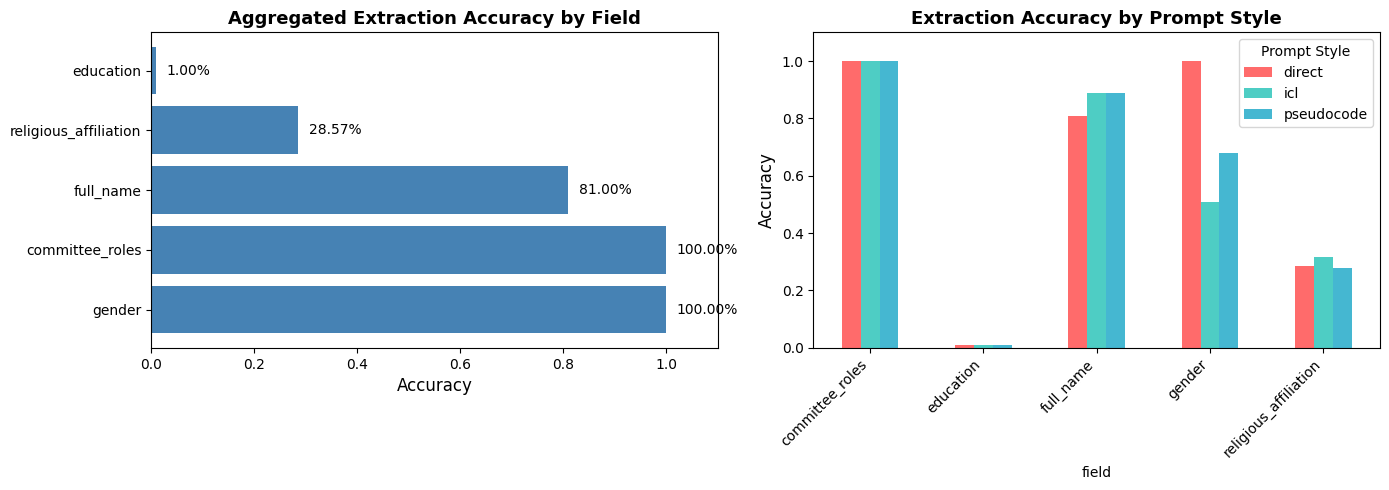

In [25]:
# Step 8: VISUALIZE RESULTS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Aggregated accuracy by field
agg_results = results_df[results_df['dataset'] == 'aggregated'].sort_values('mean', ascending=False)
axes[0].barh(agg_results['field'], agg_results['mean'], color='steelblue')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Aggregated Extraction Accuracy by Field', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1.1)
for i, (field, val) in enumerate(zip(agg_results['field'], agg_results['mean'])):
    axes[0].text(val + 0.02, i, f'{val:.2%}', va='center', fontsize=10)

# Plot 2: Accuracy by prompt style
sep_results = results_df[results_df['dataset'].str.contains('separate')]
sep_pivot = sep_results.pivot_table(index='field', columns='dataset', values='mean')
sep_pivot.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Extraction Accuracy by Prompt Style', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend(title='Prompt Style', labels=['direct', 'icl', 'pseudocode'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/accuracy_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved to: ../outputs/accuracy_comparison.png")
plt.show()

In [26]:
# Step 9: ERROR ANALYSIS - DETAILED BREAKDOWN

def analyze_field_errors(eval_df, field_name, dataset_label=''):
    """
    Identify and categorize errors for a field.
    
    Returns:
        DataFrame with columns: [senator_id, gt_value, pred_value, error_type, match_score]
        error_type: 'missing_pred', 'false_positive', 'mismatch', 'partial_match', 'correct'
    """
    
    gt_col = f"{field_name}_gt"
    pred_col = f"{field_name}_pred"
    
    errors = []
    
    for idx, row in eval_df.iterrows():
        gt_val = row[gt_col]
        pred_val = row[pred_col]
        senator_id = row.get('senator_id_gt', row.get('senator_id', 'Unknown'))
        
        # Categorize error
        if pd.isna(pred_val):
            error_type = 'missing_pred'
            match_score = 0.0
        elif pd.isna(gt_val):
            error_type = 'false_positive'
            match_score = 0.0
        else:
            # Check exact match
            if str(gt_val).lower().strip() == str(pred_val).lower().strip():
                error_type = 'correct'
                match_score = 1.0
            else:
                # Check partial match using ROUGE-1
                match_score = rouge1_score(gt_val, pred_val)
                if match_score > 0.8:
                    error_type = 'partial_match'
                elif match_score > 0:
                    error_type = 'mismatch'
                else:
                    error_type = 'false_positive'
        
        errors.append({
            'senator_id': senator_id,
            'field': field_name,
            'dataset': dataset_label,
            'gt_value': str(gt_val)[:100],  # Truncate for readability
            'pred_value': str(pred_val)[:100],
            'error_type': error_type,
            'match_score': match_score
        })
    
    return pd.DataFrame(errors)


# Analyze each field on aggregated dataset
print("="*80)
print("ERROR ANALYSIS - AGGREGATED DATASET")
print("="*80)

error_summary = {}

for field_name, _ in fields_to_eval:
    print(f"\n{field_name.upper()}")
    print("-" * 40)
    
    error_df = analyze_field_errors(eval_aggregated, field_name, 'aggregated')
    error_summary[field_name] = error_df
    
    # Count by error type
    counts = error_df['error_type'].value_counts()
    print(f"Error Type Distribution:")
    for error_type, count in counts.items():
        pct = 100 * count / len(error_df)
        print(f"  {error_type}: {count} ({pct:.1f}%)")
    
    # Show top errors (if any mismatches)
    mismatches = error_df[error_df['error_type'].isin(['mismatch', 'false_positive'])]
    if len(mismatches) > 0:
        print(f"\nTop Errors (first 3):")
        for idx, row in mismatches.head(3).iterrows():
            print(f"  GT: {row['gt_value']}")
            print(f"  PRED: {row['pred_value']}")
            print()

print("\n✓ Error analysis complete")

ERROR ANALYSIS - AGGREGATED DATASET

FULL_NAME
----------------------------------------
Error Type Distribution:
  correct: 81 (81.0%)
  mismatch: 19 (19.0%)

Top Errors (first 3):
  GT: Ashley Moody
  PRED: Senator Ashley Moody

  GT: Bill Hagerty
  PRED: Senator Bill Hagerty

  GT: Chris Coons
  PRED: Christopher Coons


GENDER
----------------------------------------
Error Type Distribution:
  correct: 100 (100.0%)

RELIGIOUS_AFFILIATION
----------------------------------------
Error Type Distribution:
  missing_pred: 58 (58.0%)
  false_positive: 26 (26.0%)
  correct: 12 (12.0%)
  mismatch: 4 (4.0%)

Top Errors (first 3):
  GT: Congregationalist
  PRED: Catholic

  GT: Protestant unspecified
  PRED: Christian

  GT: Episcopalian
  PRED: Christian


COMMITTEE_ROLES
----------------------------------------
Error Type Distribution:
  mismatch: 81 (81.0%)
  false_positive: 19 (19.0%)

Top Errors (first 3):
  GT: Senate Committee on Agriculture, Nutrition, and Forestry|Commodities, Deriv

In [27]:
# Step 10: CONSOLIDATED ERROR REPORT

print("\n" + "="*80)
print("CONSOLIDATED ERROR SUMMARY")
print("="*80)

error_report = []

for field_name, error_df in error_summary.items():
    total = len(error_df)
    correct = len(error_df[error_df['error_type'] == 'correct'])
    missing = len(error_df[error_df['error_type'] == 'missing_pred'])
    false_pos = len(error_df[error_df['error_type'] == 'false_positive'])
    partial = len(error_df[error_df['error_type'] == 'partial_match'])
    mismatch = len(error_df[error_df['error_type'] == 'mismatch'])
    
    error_report.append({
        'field': field_name,
        'total': total,
        'correct': correct,
        'correct_%': 100 * correct / total,
        'missing': missing,
        'false_positive': false_pos,
        'partial_match': partial,
        'mismatch': mismatch
    })

error_report_df = pd.DataFrame(error_report)
print(error_report_df.to_string(index=False))

# Export detailed error log
for field_name, error_df in error_summary.items():
    error_df.to_csv(f'../outputs/errors_{field_name}.csv', index=False)
    print(f"✓ Exported: ../outputs/errors_{field_name}.csv")


CONSOLIDATED ERROR SUMMARY
                field  total  correct  correct_%  missing  false_positive  partial_match  mismatch
            full_name    100       81       81.0        0               0              0        19
               gender    100      100      100.0        0               0              0         0
religious_affiliation    100       12       12.0       58              26              0         4
      committee_roles    100        0        0.0        0              19              0        81
            education    100        0        0.0        0              76              0        24
✓ Exported: ../outputs/errors_full_name.csv
✓ Exported: ../outputs/errors_gender.csv
✓ Exported: ../outputs/errors_religious_affiliation.csv
✓ Exported: ../outputs/errors_committee_roles.csv
✓ Exported: ../outputs/errors_education.csv


In [28]:
# Step 11: PER-SENATOR ERROR ANALYSIS

print("\n" + "="*80)
print("SENATORS WITH MOST EXTRACTION ERRORS")
print("="*80)

# Combine all errors
all_errors = pd.concat(error_summary.values(), ignore_index=True)

# Count errors per senator
senator_error_counts = all_errors[all_errors['error_type'] != 'correct'].groupby('senator_id').size().reset_index(name='error_count')
senator_error_counts = senator_error_counts.sort_values('error_count', ascending=False)

print("\nTop 10 Senators with Most Errors:")
print(senator_error_counts.head(10).to_string(index=False))

# Analyze error types per senator
print("\n" + "="*80)
print("ERROR PATTERNS BY SENATOR")
print("="*80)

for senator_id in senator_error_counts.head(5)['senator_id'].values:
    senator_errors = all_errors[all_errors['senator_id'] == senator_id]
    print(f"\n{senator_id}:")
    
    for field in senator_errors['field'].unique():
        field_errors = senator_errors[senator_errors['field'] == field]
        error_types = field_errors['error_type'].value_counts()
        
        for error_type, count in error_types.items():
            if error_type != 'correct':
                print(f"  {field}: {error_type} ({count})")


SENATORS WITH MOST EXTRACTION ERRORS

Top 10 Senators with Most Errors:
         senator_id  error_count
Tommy_Tuberville_AL            4
    Steve_Daines_MT            4
     John_Curtis_UT            4
    John_Boozman_AR            4
     Mark_Warner_VA            4
     Jim_Justice_WV            4
       Jim_Banks_IN            4
       Jack_Reed_RI            4
    Patty_Murray_WA            4
       Ed_Markey_MA            4

ERROR PATTERNS BY SENATOR

Tommy_Tuberville_AL:
  full_name: mismatch (1)
  religious_affiliation: false_positive (1)
  committee_roles: false_positive (1)
  education: false_positive (1)

Steve_Daines_MT:
  full_name: mismatch (1)
  religious_affiliation: missing_pred (1)
  committee_roles: false_positive (1)
  education: false_positive (1)

John_Curtis_UT:
  full_name: mismatch (1)
  religious_affiliation: false_positive (1)
  committee_roles: mismatch (1)
  education: false_positive (1)

John_Boozman_AR:
  full_name: mismatch (1)
  religious_affiliation:

In [29]:
# Step 12: SYSTEMATIC ISSUE IDENTIFICATION

print("\n" + "="*80)
print("SYSTEMATIC ISSUES BY FIELD")
print("="*80)

for field_name, error_df in error_summary.items():
    print(f"\n{field_name.upper()}")
    print("-" * 40)
    
    # Get all errors (non-correct)
    errors = error_df[error_df['error_type'] != 'correct']
    
    if len(errors) == 0:
        print("✓ No errors detected!")
        continue
    
    # Most common missing predictions
    missing = errors[errors['error_type'] == 'missing_pred']
    if len(missing) > 0:
        print(f"\nMissing Predictions: {len(missing)}")
        print("  Representative cases:")
        for idx, row in missing.head(2).iterrows():
            print(f"    - {row['senator_id']}: GT='{row['gt_value']}'")
    
    # False positives
    false_pos = errors[errors['error_type'] == 'false_positive']
    if len(false_pos) > 0:
        print(f"\nFalse Positives: {len(false_pos)}")
        print("  These are extracted but GT is empty")
        for idx, row in false_pos.head(2).iterrows():
            print(f"    - {row['senator_id']}: Pred='{row['pred_value']}'")
    
    # Mismatches
    mismatch = errors[errors['error_type'] == 'mismatch']
    if len(mismatch) > 0:
        print(f"\nMismatches: {len(mismatch)}")
        print("  GT vs. Pred with low overlap:")
        for idx, row in mismatch.head(2).iterrows():
            print(f"    - GT: '{row['gt_value']}'")
            print(f"    - Pred: '{row['pred_value']}'")

print("\n✓ Systematic analysis complete")


SYSTEMATIC ISSUES BY FIELD

FULL_NAME
----------------------------------------

Mismatches: 19
  GT vs. Pred with low overlap:
    - GT: 'Ashley Moody'
    - Pred: 'Senator Ashley Moody'
    - GT: 'Bill Hagerty'
    - Pred: 'Senator Bill Hagerty'

GENDER
----------------------------------------
✓ No errors detected!

RELIGIOUS_AFFILIATION
----------------------------------------

Missing Predictions: 58
  Representative cases:
    - Alan_Armstrong_OK: GT='nan'
    - Alex_Padilla_CA: GT='Catholic'

False Positives: 26
  These are extracted but GT is empty
    - Amy_Klobuchar_MN: Pred='Catholic'
    - Bill_Cassidy_LA: Pred='Christian'

Mismatches: 4
  GT vs. Pred with low overlap:
    - GT: 'Baptist'
    - Pred: 'Baptist Church'
    - GT: 'Baptist'
    - Pred: 'Macedonia Baptist Church'

COMMITTEE_ROLES
----------------------------------------

False Positives: 19
  These are extracted but GT is empty
    - Alan_Armstrong_OK: Pred='['Senator', 'Energy', 'Judiciary', 'Banking']'
    - Ca

✓ Visualization saved to: ../outputs/error_analysis.png


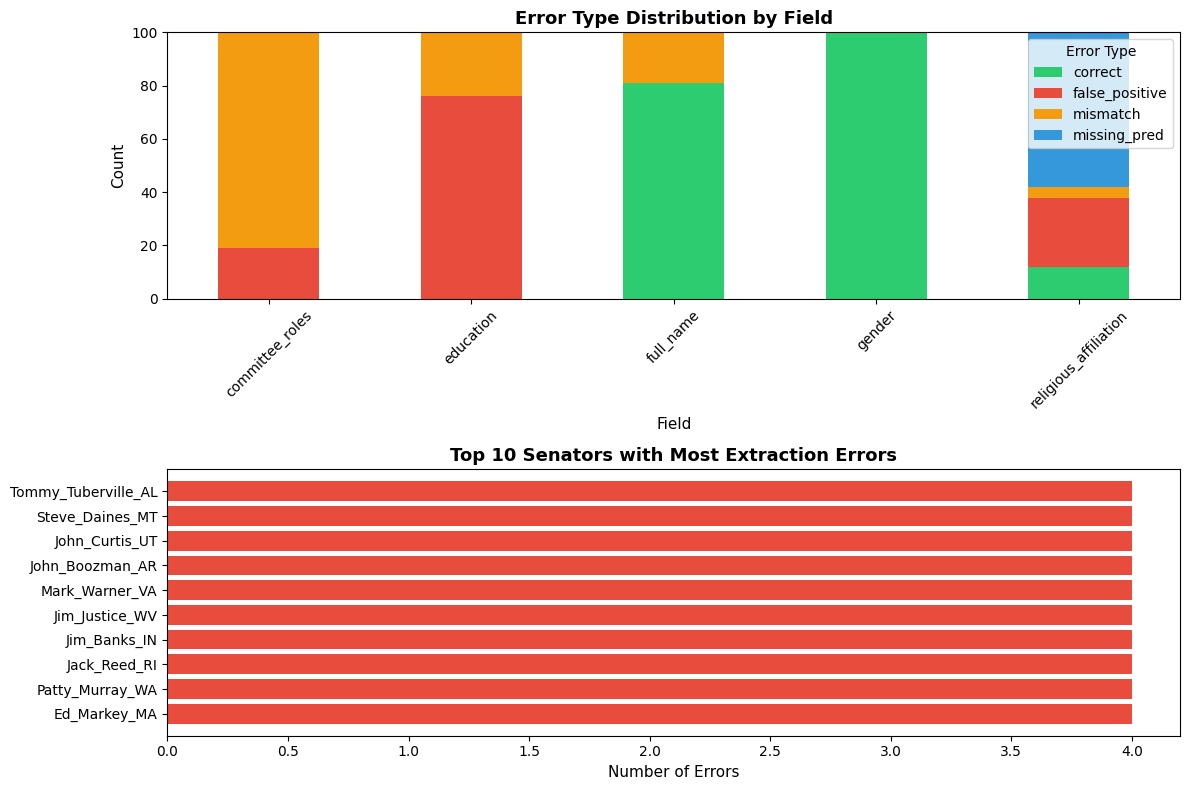

In [30]:
# Step 13: VISUALIZE ERROR PATTERNS

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Error type distribution by field
error_type_summary = all_errors.groupby(['field', 'error_type']).size().unstack(fill_value=0)
error_type_summary.plot(kind='bar', stacked=True, ax=axes[0], 
                        color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#95a5a6'])
axes[0].set_title('Error Type Distribution by Field', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xlabel('Field', fontsize=11)
axes[0].legend(title='Error Type', loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Senators with most errors
top_error_senators = senator_error_counts.head(10)
axes[1].barh(range(len(top_error_senators)), top_error_senators['error_count'].values, color='#e74c3c')
axes[1].set_yticks(range(len(top_error_senators)))
axes[1].set_yticklabels(top_error_senators['senator_id'].values)
axes[1].set_xlabel('Number of Errors', fontsize=11)
axes[1].set_title('Top 10 Senators with Most Extraction Errors', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/error_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved to: ../outputs/error_analysis.png")
plt.show()